### Setup and Data Download
Install the necessary libraries and download the CWRU Bearing Dataset. Kagglehub is used to directly download the latest version of the dataset and cache it locally.

In [1]:
# Standard data manipulation and visualization imports
import os
import glob
import numpy as np
import scipy.io
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
import random
import time
import tqdm as notebook_tqdm

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Kaggle dataset download
import kagglehub

# Download latest version of the CWRU dataset
dataset_path = kagglehub.dataset_download("brjapon/cwru-bearing-datasets")
print("Path to dataset files:", dataset_path)

# Prep folder for saving plots
folder_name = "plots"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

c:\Users\Spencer Kenison\OneDrive - USU\STAT 6685 Deep Learning Theory & Applications\04_Final_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Spencer Kenison\.cache\kagglehub\datasets\brjapon\cwru-bearing-datasets\versions\1


### Data Segmentation and Standardization

The raw 1D time-series data from the CWRU files is continuous and high-frequency. A sliding window approach is used to segment the continuous drive-end (DE) accelerometer readings into discrete chunks of 1024 data points.

After segmenting the data, the segments are normalized using z-score standardization and split the data into 70% training, 15% validation, and 15% testing sets with stratification to ensure all mechanical fault types are represented equally across the sets.

In [2]:
WINDOW_SIZE = 1024
STRIDE = 1024  

def load_and_segment_cwru_data_multichannel(base_path):
    X = []
    y = []
    
    class_mapping = {
        'normal': 0,
        'ir': 1,      
        'or': 2,      
        'b': 3        
    }
    
    all_files = glob.glob(os.path.join(base_path, '**', '*.mat'), recursive=True)
    
    if not all_files: raise ValueError("No .mat files found in the dataset path. Please verify the dataset structure.")
        
    for file_path in all_files:
        file_name = os.path.basename(file_path).lower()
        
        label = None
        for key, val in class_mapping.items():
            if key in file_name:
                label = val
                break
        
        if label is None: continue 
            
        try:
            mat_data = scipy.io.loadmat(file_path)
            
            # Find both Drive End (DE) and Fan End (FE) keys
            de_key, fe_key = None, None
            for key in mat_data.keys():
                if 'de_time' in key.lower():
                    de_key = key
                elif 'fe_time' in key.lower():
                    fe_key = key
            
            if de_key is None:
                continue # DE is our primary signal; skip if missing
                
            raw_de = mat_data[de_key].flatten()
            
            # If FE is missing in this specific file, fill with zeros to maintain the matrix shape
            if fe_key is not None:
                raw_fe = mat_data[fe_key].flatten()
            else:
                raw_fe = np.zeros_like(raw_de)
                print("Missing fe value")
            
            # Sliding window segmentation for both channels
            for i in range(0, len(raw_de) - WINDOW_SIZE, STRIDE):
                segment_de = raw_de[i : i + WINDOW_SIZE]
                segment_fe = raw_fe[i : i + WINDOW_SIZE]
                
                if len(segment_de) == WINDOW_SIZE:
                    # Stack them to create a shape of (2, 1024) -> (Channels, Sequence_Length)
                    combined_segment = np.vstack((segment_de, segment_fe))
                    X.append(combined_segment)
                    y.append(label)
                    
        except Exception as e:
            print(f"Error reading {file_name}: {e}")
            
    return np.array(X), np.array(y)

# Load and segment 
print("Extracting multi-channel data from .mat files...")
X_raw, y_raw = load_and_segment_cwru_data_multichannel(dataset_path)

if len(X_raw) == 0:
    raise ValueError("No data was extracted.")

print(f"Total extracted segments: {len(X_raw)}")
print(f"Raw array shape: {X_raw.shape}") # Expected: (samples, 2, 1024)
print(f"Class distribution (0:Normal, 1:IR, 2:OR, 3:Ball): {np.bincount(y_raw)}")

# Train/Val/Test Split (70%, 15%, 15%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_raw, test_size=0.30, stratify=y_raw, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# Z-score Standardization for 3D Arrays
scaler = StandardScaler()

# Flatten the (channels, sequence) dimensions to 2D for the scaler, then reshape back to 3D
samples_train, channels, window = X_train.shape
X_train = scaler.fit_transform(X_train.reshape(samples_train, -1)).reshape(samples_train, channels, window)
samples_val = X_val.shape[0]
X_val = scaler.transform(X_val.reshape(samples_val, -1)).reshape(samples_val, channels, window)
samples_test = X_test.shape[0]
X_test = scaler.transform(X_test.reshape(samples_test, -1)).reshape(samples_test, channels, window)

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Extracting multi-channel data from .mat files...
Total extracted segments: 4640
Raw array shape: (4640, 2, 1024)
Class distribution (0:Normal, 1:IR, 2:OR, 3:Ball): [ 472 1319 1425 1424]
Train shape: (3248, 2, 1024), Val shape: (696, 2, 1024), Test shape: (696, 2, 1024)


### Plot Sample Data

Plot the X_train samples to visualize the signals for reference.

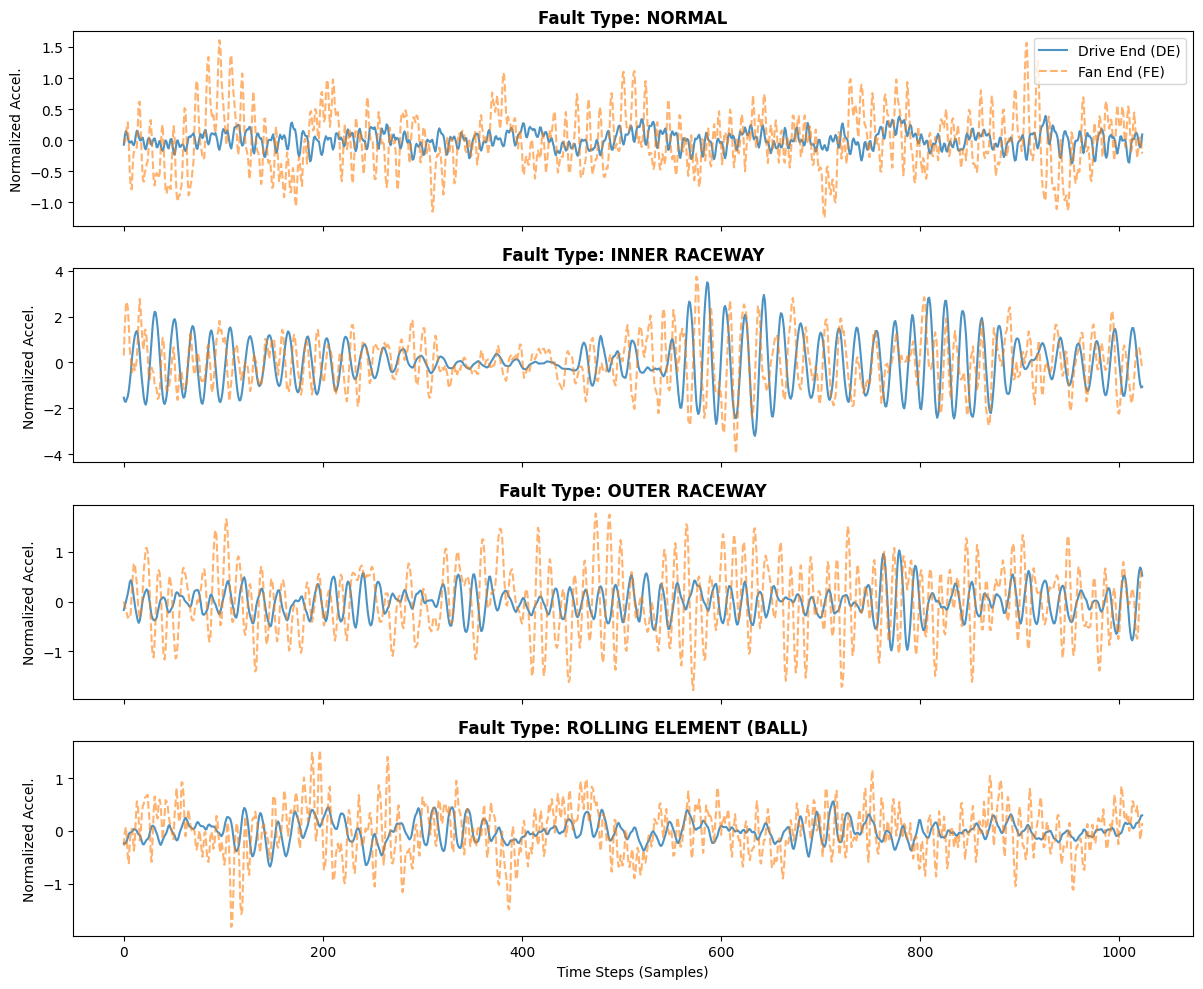

In [3]:
def plot_fault_samples(X, y, class_mapping):
    classes = list(class_mapping.keys())
    fig, axes = plt.subplots(len(classes), 1, figsize=(12, 10), sharex=True)
    
    for i, class_name in enumerate(classes):
        # Find the first index belonging to this class
        idx = np.where(y == class_mapping[class_name])[0][0]
        sample = X[idx] # Shape (2, 1024)
        
        # Plot Drive End (Channel 0) and Fan End (Channel 1)
        axes[i].plot(sample[0], label='Drive End (DE)', alpha=0.8)
        axes[i].plot(sample[1], label='Fan End (FE)', alpha=0.6, linestyle='--')
        axes[i].set_title(f"Fault Type: {class_name.upper()}", fontweight='bold')
        axes[i].set_ylabel("Normalized Accel.")
        if i == 0:
            axes[i].legend(loc='upper right')
            
    plt.xlabel("Time Steps (Samples)")
    plt.tight_layout()
    plt.savefig(f"{folder_name}/x_train_data_plot.png", bbox_inches='tight', dpi=300); plt.show()

# Define the mapping manually since it was local to the function
class_map = {'normal': 0, 'Inner Raceway': 1, 'Outer Raceway': 2, 'Rolling Element (Ball)': 3}

# Call the function
plot_fault_samples(X_train, y_train, class_map)

### PyTorch Dataset Preparation

The numpy arrays have both the Drive End and Fan End sensor readings with the shape: (samples, 2, 1024). By converting to PyTorch Tensors, a channel dimension does not need to be artificially added. The PyTorch Tensors are wrapped in DataLoader objects to feed the neural network in batches.

In [4]:
class CWRUDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_loader = DataLoader(CWRUDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CWRUDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(CWRUDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

# Verify a single batch shape
dataiter = iter(train_loader)
inputs, labels = next(dataiter)
print(f"Batch inputs shape: {inputs.shape}") # Expected: (64, 2, 1024)
print(f"Batch labels shape: {labels.shape}") # Expected: (64)

Batch inputs shape: torch.Size([64, 2, 1024])
Batch labels shape: torch.Size([64])


### Model Architecture: Multi-Channel 1D CNN + RNN Architecture

Two parallel sensor signals are fed into the network simultaneously, meaning the first convolutional layer must be updated to accept in_channels=2. The CNN will learn to extract features from the combined relationship between the Drive End and Fan End vibrations before passing the downsampled sequence to the LSTM

In [5]:
class CNN_RNN_FaultDetector(nn.Module):
    def __init__(self, num_classes=4):
        super(CNN_RNN_FaultDetector, self).__init__()
        
        # 1D CNN for multi-channel feature extraction
        self.cnn = nn.Sequential(
            # Input: (Batch, 2, 1024) -> Output: (Batch, 16, 481)
            # in_channels is 2 to accept both DE and FE sensors
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=64, stride=2),
            nn.ReLU(),
            # Output: (Batch, 16, 240)
            nn.MaxPool1d(kernel_size=2),
            
            # Input: (Batch, 16, 240) -> Output: (Batch, 32, 105)
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=32, stride=2),
            nn.ReLU(),
            # Output: (Batch, 32, 52)
            nn.MaxPool1d(kernel_size=2)
        )
        
        # RNN (LSTM) for sequence memory
        # Input size is 32 (from CNN channels), sequence length is 52
        self.rnn = nn.LSTM(input_size=32, hidden_size=64, num_layers=1, batch_first=True)
        
        # MLP / Fully Connected Head
        self.mlp = nn.Sequential(
            nn.Dropout(0.5), # Regularization
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
        
        self._initialize_weights()

    def forward(self, x):
        # x shape: (batch_size, 2, 1024)
        x = self.cnn(x)
        
        # Prepare for RNN: swap dimensions to (batch_size, seq_len, features)
        # x shape becomes: (batch_size, 52, 32)
        x = x.permute(0, 2, 1) 
        
        # RNN outputs: out, (h_n, c_n)
        rnn_out, (h_n, c_n) = self.rnn(x)
        
        # Take the output of the final time step
        final_state = rnn_out[:, -1, :] 
        
        # Pass through MLP
        logits = self.mlp(final_state)
        return logits

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                # He initialization for ReLU activation layers
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

# Create an instance of the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN_RNN_FaultDetector(num_classes=4).to(device)
print(f"Model successfully loaded on: {device}")

Model successfully loaded on: cpu


### Training Loop: Optimization and Regularization

The multi-channel CNN-RNN network is trained using the Cross-Entropy loss function, which is standard for multiclass classification problems. Optimization relies on Stochastic Gradient Descent (SGD) with momentum to minimize loss.

To prevent overfitting, L2 weight decay is applied directly within the SGD optimizer using the Dropout layer defined in the model. Both the training and validation metrics are tracked across epochs to ensure the model is generalizing well.

Starting training loop...
Epoch [01/30] - Train Loss: 0.9706, Train Acc: 0.5674 | Val Loss: 0.6249, Val Acc: 0.6983 | Avg Time: 1.65s/epoch
Epoch [05/30] - Train Loss: 0.1516, Train Acc: 0.9544 | Val Loss: 1.0599, Val Acc: 0.8204 | Avg Time: 1.42s/epoch
Epoch [10/30] - Train Loss: 0.1371, Train Acc: 0.9634 | Val Loss: 0.1500, Val Acc: 0.9440 | Avg Time: 1.40s/epoch
Epoch [15/30] - Train Loss: 0.0229, Train Acc: 0.9945 | Val Loss: 0.0475, Val Acc: 0.9871 | Avg Time: 1.39s/epoch
Epoch [20/30] - Train Loss: 0.0062, Train Acc: 0.9985 | Val Loss: 0.0114, Val Acc: 0.9971 | Avg Time: 1.41s/epoch
Epoch [25/30] - Train Loss: 0.0160, Train Acc: 0.9960 | Val Loss: 0.0098, Val Acc: 0.9971 | Avg Time: 1.41s/epoch
Epoch [30/30] - Train Loss: 0.0013, Train Acc: 1.0000 | Val Loss: 0.0003, Val Acc: 1.0000 | Avg Time: 1.40s/epoch
Model weights successfully saved to: cwru_cnn_rnn_weights.pth


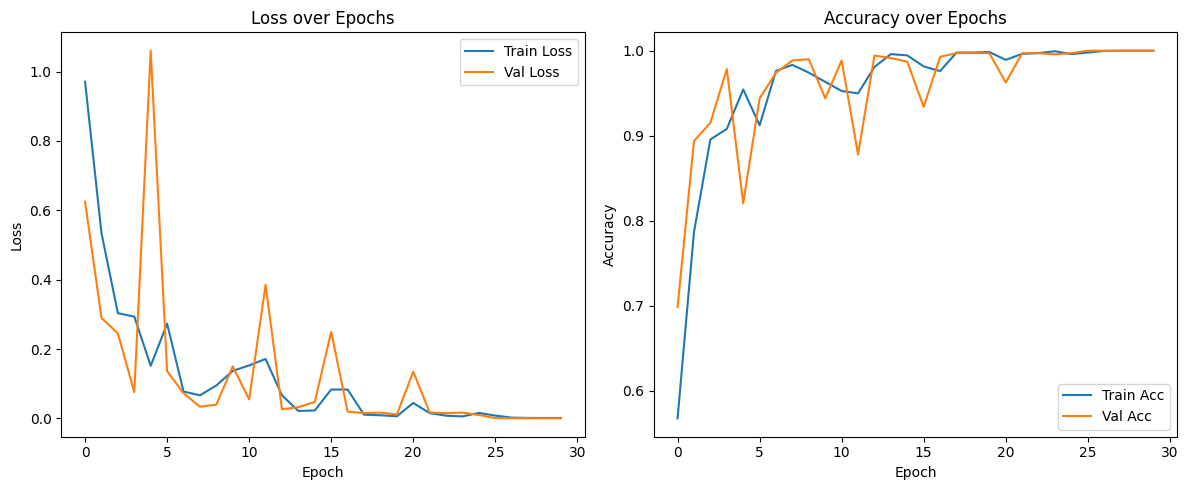

In [6]:
# Hyperparameters
EPOCHS = 30
LEARNING_RATE = 0.01
WEIGHT_DECAY = 1e-4 # L2 Regularization
MOMENTUM = 0.9

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

# Tracking history for plotting
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print("Starting training loop...")
total_training_time = 0.0

for epoch in range(EPOCHS):
    # Training Phase
    start_time = time.time()
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    # Validation Phase
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    epoch_val_loss = val_loss / total
    epoch_val_acc = correct / total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    total_training_time += (time.time() - start_time)
    avg_time = total_training_time / (epoch + 1)
    
    # Print progress every 5 epochs and on the first/last epoch
    if (epoch + 1) == 1 or (epoch + 1) % 5 == 0 or (epoch + 1) == EPOCHS:
        print(f"Epoch [{epoch+1:02d}/{EPOCHS}] - "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f} | "
              f"Avg Time: {avg_time:.2f}s/epoch")

# Define the file path for the saved model
MODEL_PATH = "cwru_cnn_rnn_weights.pth"
torch.save(model.state_dict(), MODEL_PATH) # Save only the model parameters (recommended practice in PyTorch)
print(f"Model weights successfully saved to: {MODEL_PATH}")

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(f"{folder_name}/loss_accuracy_over_epochs.png", bbox_inches='tight', dpi=300); plt.show()

Final Test Accuracy: 100.00%

Classification Report:
                   precision    recall  f1-score   support

           Normal       1.00      1.00      1.00        71
Inner Race Defect       1.00      1.00      1.00       198
Outer Race Defect       1.00      1.00      1.00       214
      Ball Defect       1.00      1.00      1.00       213

         accuracy                           1.00       696
        macro avg       1.00      1.00      1.00       696
     weighted avg       1.00      1.00      1.00       696



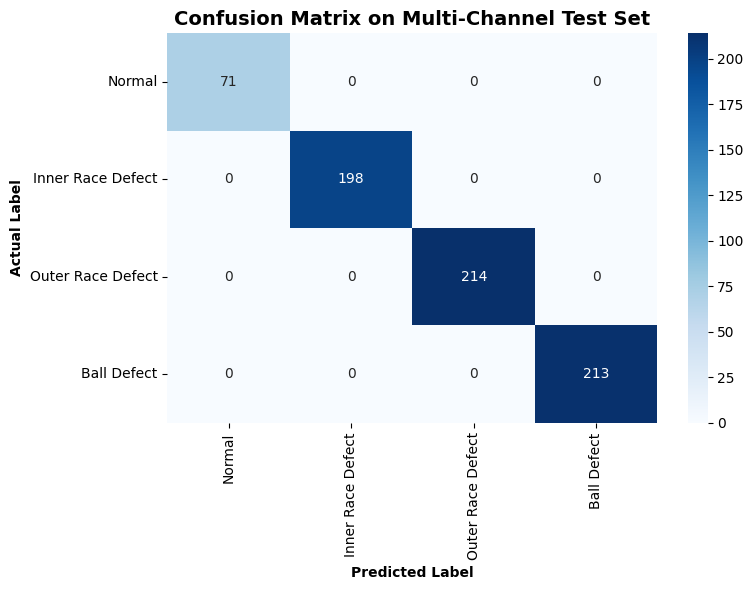

In [7]:
# Set model to evaluation mode
model.eval()
all_preds = []
all_labels = []

# Disable gradient calculation for inference
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        # Move back to CPU for scikit-learn metrics
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate overall accuracy
test_acc = accuracy_score(all_labels, all_preds)
print(f"Final Test Accuracy: {test_acc * 100:.2f}%\n")

# Precision, Recall, F1-Score
print("Classification Report:")
class_names = ['Normal', 'Inner Race Defect', 'Outer Race Defect', 'Ball Defect']
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.title('Confusion Matrix on Multi-Channel Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{folder_name}/confusion_matrix.png", bbox_inches='tight', dpi=300); plt.show()

### Test Model Perfomance w/ Noise

The model trained without noise added is tested with noise added to better understand the effects of noise on the system.

Starting robustness evaluation across various SNR levels...
SNR:  30 dB | Test Accuracy: 100.00%
SNR:  25 dB | Test Accuracy: 100.00%
SNR:  20 dB | Test Accuracy: 100.00%
SNR:  15 dB | Test Accuracy: 100.00%
SNR:  10 dB | Test Accuracy: 99.86%
SNR:   5 dB | Test Accuracy: 99.71%
SNR:   4 dB | Test Accuracy: 98.56%
SNR:   3 dB | Test Accuracy: 97.27%
SNR:   2 dB | Test Accuracy: 95.26%
SNR:   1 dB | Test Accuracy: 90.37%
SNR:   0 dB | Test Accuracy: 85.06%
SNR:  -1 dB | Test Accuracy: 82.04%
SNR:  -2 dB | Test Accuracy: 77.16%
SNR:  -3 dB | Test Accuracy: 72.70%
SNR:  -4 dB | Test Accuracy: 70.11%
SNR:  -5 dB | Test Accuracy: 64.51%
SNR:  -6 dB | Test Accuracy: 55.32%
SNR:  -7 dB | Test Accuracy: 52.30%
SNR:  -8 dB | Test Accuracy: 46.26%
SNR:  -9 dB | Test Accuracy: 42.53%
SNR: -10 dB | Test Accuracy: 39.66%


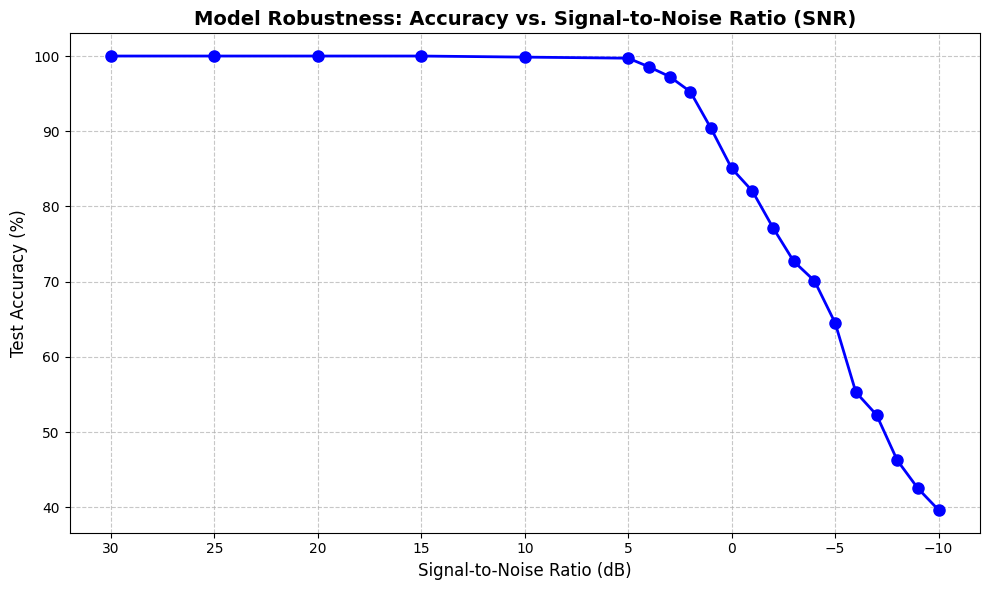


Generating Confusion Matrix for Regular Model at SNR: 0 dB
Regular Model Classification Report at High Noise (0 dB):
                   precision    recall  f1-score   support

           Normal       1.00      0.27      0.42        71
Inner Race Defect       0.98      0.81      0.89       198
Outer Race Defect       0.78      0.99      0.87       214
      Ball Defect       0.84      0.96      0.90       213

         accuracy                           0.86       696
        macro avg       0.90      0.76      0.77       696
     weighted avg       0.88      0.86      0.84       696



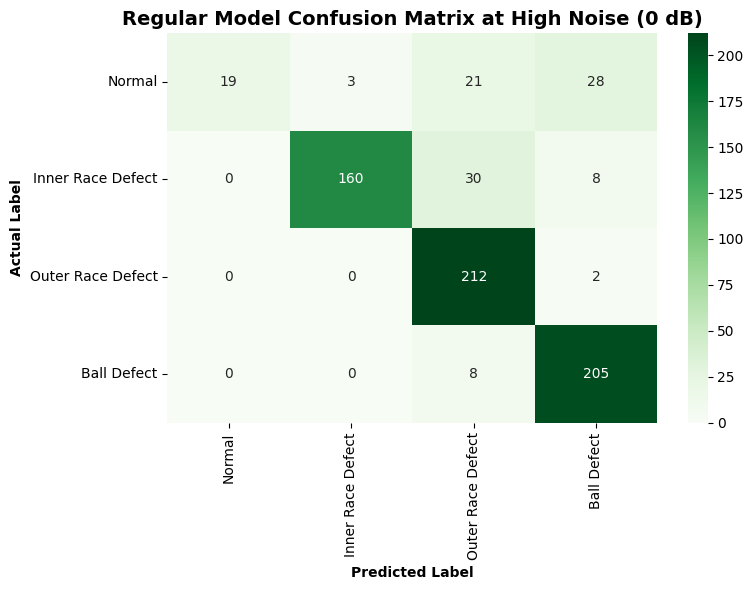

In [ ]:
def add_awgn_to_batch(batch_inputs, snr_db):
    # Calculate the power of the signal for each sample in the batch
    # Averaging over channels and sequence length
    signal_power = torch.mean(batch_inputs ** 2, dim=[1, 2], keepdim=True)
    
    # Convert SNR from decibels to a linear scale
    snr_linear = 10 ** (snr_db / 10.0)
    
    # Calculate the required noise power
    noise_power = signal_power / snr_linear
    
    # Generate Gaussian noise with mean=0 and variance=noise_power (std = sqrt(variance))
    noise = torch.randn_like(batch_inputs) * torch.sqrt(noise_power)
    
    return batch_inputs + noise

def evaluate_model_robustness(model, test_loader, snr_levels, device):
    print("Starting robustness evaluation across various SNR levels...")
    model.eval() # Ensure model is in evaluation mode
    snr_accuracies = []
    
    for snr in snr_levels:
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Inject noise into the clean inputs
                noisy_inputs = add_awgn_to_batch(inputs, snr)
                
                # Run inference
                outputs = model(noisy_inputs)
                _, preds = torch.max(outputs, 1)
                
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                
        # Calculate accuracy for this SNR level
        acc = correct / total
        snr_accuracies.append(acc)
        print(f"SNR: {snr:3d} dB | Test Accuracy: {acc * 100:.2f}%")
        
    return snr_accuracies

# Define the SNR levels to test (from clean to extremely noisy)
snr_range = [30, 25, 20, 15, 10, 5, 4, 3, 2, 1, 0, -1, -2, -3, -4, -5, -6, -7, -8, -9, -10]

# Run the evaluation
robustness_accuracies = evaluate_model_robustness(model, test_loader, snr_range, device)

# Plot the SNR vs. Accuracy Curve
plt.figure(figsize=(10, 6))
plt.plot(snr_range, [acc * 100 for acc in robustness_accuracies], 
         marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

# Formatting the plot
plt.title('Model Robustness: Accuracy vs. Signal-to-Noise Ratio (SNR)', fontsize=14, fontweight='bold')
plt.xlabel('Signal-to-Noise Ratio (dB)', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Invert X-axis so it reads left-to-right from Clean (High SNR) to Noisy (Low SNR)
plt.gca().invert_xaxis() 

# Save and show
plt.tight_layout()
plt.savefig(f"{folder_name}/robustness_snr_curve.png", bbox_inches='tight', dpi=300); plt.show()

# Highest Noise Level Confusion Matrix
lowest_snr = 0 #np.min(snr_range) # Set the highest noise level (lowest SNR) from your tested range

# Evaluation for Regular (Clean-Trained) Model at Lowest SNR 
print(f"\nGenerating Confusion Matrix for Regular Model at SNR: {lowest_snr} dB")

# Set regular model to evaluation mode
model.eval()
regular_noisy_preds = []
regular_noisy_labels = []

# Disable gradient calculation for inference
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # Inject the highest level of noise
        noisy_inputs = add_awgn_to_batch(inputs, snr_db=lowest_snr)
        
        # Run inference on the regular model
        outputs = model(noisy_inputs)
        _, preds = torch.max(outputs, 1)
        
        # Move back to CPU for scikit-learn metrics
        regular_noisy_preds.extend(preds.cpu().numpy())
        regular_noisy_labels.extend(labels.cpu().numpy())
        
# Highest Noise Level Classification Report for Regular Model
print(f"Regular Model Classification Report at High Noise ({lowest_snr} dB):")
print(classification_report(regular_noisy_labels, regular_noisy_preds, target_names=class_names))

# Calculate Confusion Matrix
cm_regular_noisy = confusion_matrix(regular_noisy_labels, regular_noisy_preds)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
# Using 'Blues' cmap to visually distinguish it from the robust model's 'Reds' heatmap
sns.heatmap(cm_regular_noisy, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.title(f'Regular Model Confusion Matrix at High Noise ({lowest_snr} dB)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{folder_name}/regular_confusion_matrix_highest_noise.png", bbox_inches='tight', dpi=300)
plt.show()

### Training with Noise Injection (Data Augmentation)
To make the model more resilient to real-world factory conditions, a new model is trained using Additive White Gaussian Noise (AWGN) for data augmentation.


Starting robust training loop with added noise...
Epoch [01/50] - Train Loss: 1.1230, Train Acc: 0.4880 | Val Loss: 0.6944, Val Acc: 0.6925 | Avg Time: 1.65s/epoch
Epoch [05/50] - Train Loss: 0.3314, Train Acc: 0.8747 | Val Loss: 0.1794, Val Acc: 0.9296 | Avg Time: 1.56s/epoch
Epoch [10/50] - Train Loss: 0.2527, Train Acc: 0.9147 | Val Loss: 0.1527, Val Acc: 0.9339 | Avg Time: 1.56s/epoch
Epoch [15/50] - Train Loss: 0.2917, Train Acc: 0.9058 | Val Loss: 0.4207, Val Acc: 0.8721 | Avg Time: 1.56s/epoch
Epoch [20/50] - Train Loss: 0.2489, Train Acc: 0.9246 | Val Loss: 0.1383, Val Acc: 0.9684 | Avg Time: 1.55s/epoch
Epoch [25/50] - Train Loss: 0.1434, Train Acc: 0.9609 | Val Loss: 0.0975, Val Acc: 0.9655 | Avg Time: 1.52s/epoch
Epoch [30/50] - Train Loss: 0.0460, Train Acc: 0.9901 | Val Loss: 0.0305, Val Acc: 0.9899 | Avg Time: 1.51s/epoch
Epoch [35/50] - Train Loss: 0.0259, Train Acc: 0.9945 | Val Loss: 0.0126, Val Acc: 0.9957 | Avg Time: 1.51s/epoch
Epoch [40/50] - Train Loss: 0.0376, Tr

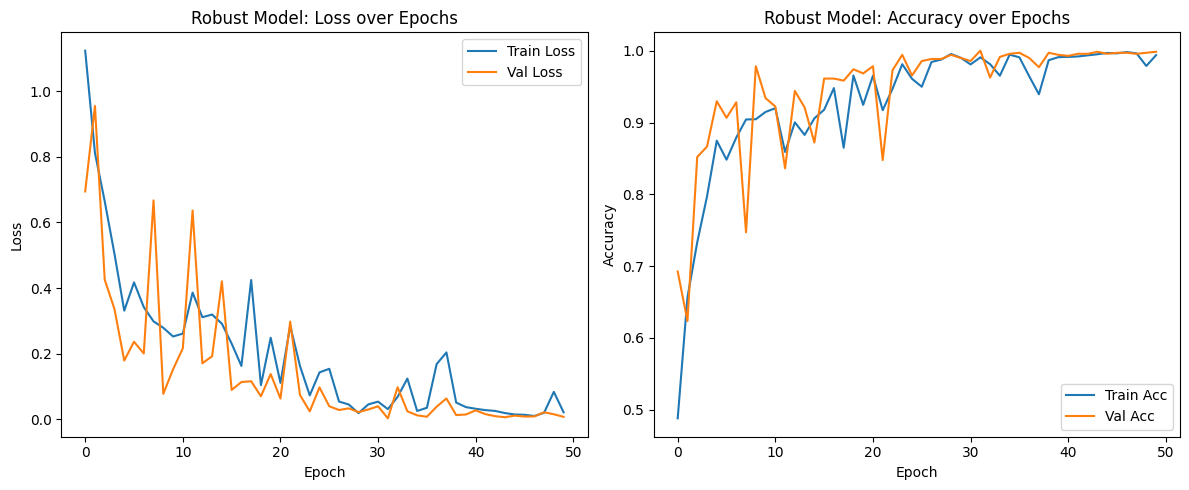

In [9]:

EPOCHS = 50

# Fresh model for robust training with noise
robust_model = CNN_RNN_FaultDetector(num_classes=4).to(device)

# Loss and Optimizer (using the same hyperparameters as before)
robust_optimizer = optim.SGD(robust_model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

# Tracking history
robust_train_losses, robust_val_losses = [], []
robust_train_accuracies, robust_val_accuracies = [], []

print("Starting robust training loop with added noise...")
total_training_time = 0

for epoch in range(EPOCHS):
    # Training Phase (With Noise)
    start_time = time.time()
    robust_model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Inject random noise between 0dB (very noisy) and 30dB (very clean)
        # This forces the model to learn across a variety of acoustic environments
        batch_snr = random.uniform(-5, 30)
        noisy_inputs = add_awgn_to_batch(inputs, batch_snr)
        
        robust_optimizer.zero_grad()
        outputs = robust_model(noisy_inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        robust_optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    robust_train_losses.append(epoch_train_loss)
    robust_train_accuracies.append(epoch_train_acc)
    
    # Validation Phase (With Fixed Noise)
    robust_model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Apply a fixed moderate noise (e.g., 10 dB) for consistent validation tracking
            noisy_val_inputs = add_awgn_to_batch(inputs, snr_db=10)
            
            outputs = robust_model(noisy_val_inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    epoch_val_loss = val_loss / total
    epoch_val_acc = correct / total
    robust_val_losses.append(epoch_val_loss)
    robust_val_accuracies.append(epoch_val_acc)
    
    #Calculate time
    total_training_time += (time.time() - start_time)
    avg_time = total_training_time / (epoch + 1)
    
    # Print progress
    if (epoch + 1) == 1 or (epoch + 1) % 5 == 0 or (epoch + 1) == EPOCHS:
        print(f"Epoch [{epoch+1:02d}/{EPOCHS}] - "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f} | "
              f"Avg Time: {avg_time:.2f}s/epoch")

# Save the robust model
ROBUST_MODEL_PATH = "cwru_cnn_rnn_robust_weights.pth"
torch.save(robust_model.state_dict(), ROBUST_MODEL_PATH)
print(f"Robust model weights successfully saved to: {ROBUST_MODEL_PATH}")

# Plot robust model training history
plt.figure(figsize=(12, 5))

# Plot 1: Loss over Epochs
plt.subplot(1, 2, 1)
plt.plot(robust_train_losses, label='Train Loss')
plt.plot(robust_val_losses, label='Val Loss')
plt.title('Robust Model: Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot 2: Accuracy over Epochs
plt.subplot(1, 2, 2)
plt.plot(robust_train_accuracies, label='Train Acc')
plt.plot(robust_val_accuracies, label='Val Acc')
plt.title('Robust Model: Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Formatting and saving
plt.tight_layout()
plt.savefig(f"{folder_name}/robust_loss_accuracy_over_epochs.png", bbox_inches='tight', dpi=300)
plt.show()

### Robustness Comparison
Evaluate the newly trained robust model across the same SNR range used previously and plot the results side-by-side to show improvement


Evaluating Noise-Trained Model Robustness...
Starting robustness evaluation across various SNR levels...
SNR:  30 dB | Test Accuracy: 99.57%
SNR:  25 dB | Test Accuracy: 99.71%
SNR:  20 dB | Test Accuracy: 99.71%
SNR:  15 dB | Test Accuracy: 99.57%
SNR:  10 dB | Test Accuracy: 99.57%
SNR:   5 dB | Test Accuracy: 99.57%
SNR:   4 dB | Test Accuracy: 99.71%
SNR:   3 dB | Test Accuracy: 99.57%
SNR:   2 dB | Test Accuracy: 99.43%
SNR:   1 dB | Test Accuracy: 99.43%
SNR:   0 dB | Test Accuracy: 98.99%
SNR:  -1 dB | Test Accuracy: 98.56%
SNR:  -2 dB | Test Accuracy: 98.71%
SNR:  -3 dB | Test Accuracy: 97.13%
SNR:  -4 dB | Test Accuracy: 95.83%
SNR:  -5 dB | Test Accuracy: 93.97%
SNR:  -6 dB | Test Accuracy: 89.80%
SNR:  -7 dB | Test Accuracy: 83.05%
SNR:  -8 dB | Test Accuracy: 76.58%
SNR:  -9 dB | Test Accuracy: 65.09%
SNR: -10 dB | Test Accuracy: 58.91%


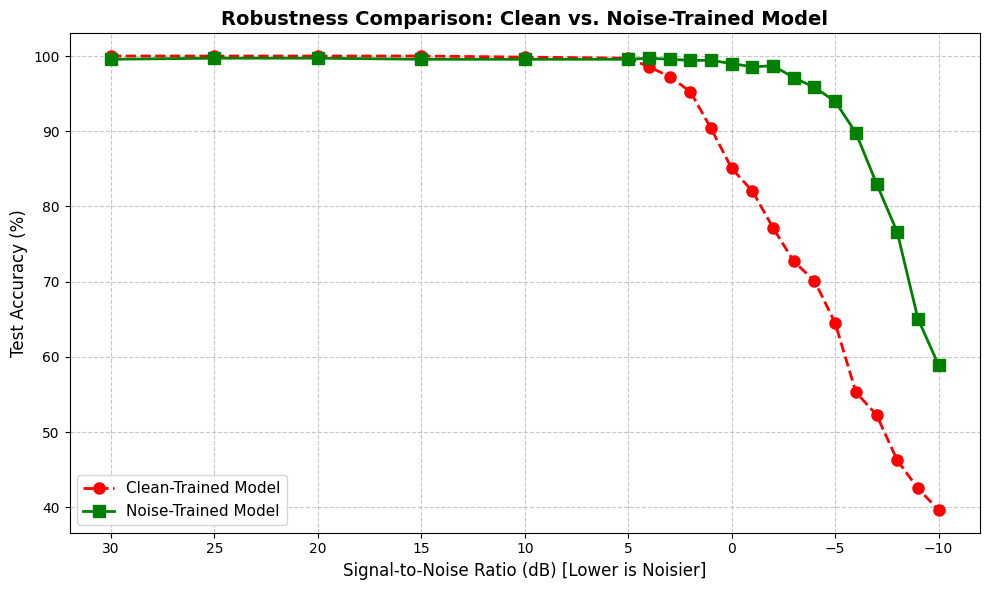


Generating Confusion Matrix for Robust Model at SNR: 0 dB
Classification Report at High Noise (0 dB):
                   precision    recall  f1-score   support

           Normal       1.00      1.00      1.00        71
Inner Race Defect       0.99      1.00      1.00       198
Outer Race Defect       0.98      1.00      0.99       214
      Ball Defect       1.00      0.98      0.99       213

         accuracy                           0.99       696
        macro avg       0.99      0.99      0.99       696
     weighted avg       0.99      0.99      0.99       696



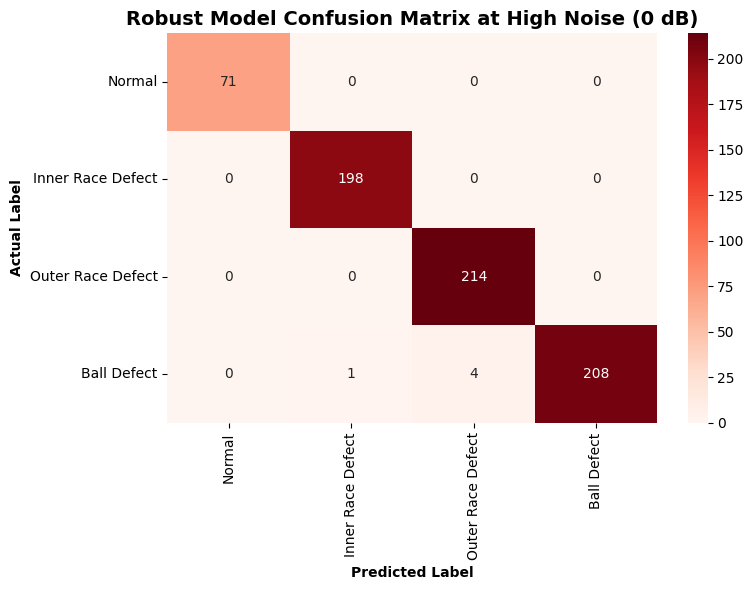

In [10]:

# Evaluate the newly trained robust model across the same SNR range
print("\nEvaluating Noise-Trained Model Robustness...")
robust_model_accuracies = evaluate_model_robustness(robust_model, test_loader, snr_range, device)

# Plot the comparison
plt.figure(figsize=(10, 6))

# Original model (Clean trained) - relies on the 'robustness_accuracies' calculated earlier in the script
plt.plot(snr_range, [acc * 100 for acc in robustness_accuracies], 
         marker='o', linestyle='--', color='red', linewidth=2, markersize=8, label='Clean-Trained Model')

# Robust model (Noise trained)
plt.plot(snr_range, [acc * 100 for acc in robust_model_accuracies], 
         marker='s', linestyle='-', color='green', linewidth=2, markersize=8, label='Noise-Trained Model')

# Formatting the plot
plt.title('Robustness Comparison: Clean vs. Noise-Trained Model', fontsize=14, fontweight='bold')
plt.xlabel('Signal-to-Noise Ratio (dB) [Lower is Noisier]', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower left', fontsize=11)
plt.gca().invert_xaxis() # Invert X-axis so it reads left-to-right from Clean (High SNR) to Noisy (Low SNR)
plt.tight_layout()
plt.savefig(f"{folder_name}/robustness_comparison_snr.png", bbox_inches='tight', dpi=300)
plt.show()

print(f"\nGenerating Confusion Matrix for Robust Model at SNR: {lowest_snr} dB")

# Set robust model to evaluation mode
robust_model.eval()
noisy_preds = []
noisy_labels = []

# Disable gradient calculation for inference
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # Inject the highest level of noise
        noisy_inputs = add_awgn_to_batch(inputs, snr_db=lowest_snr)
        
        # Run inference on the robust model
        outputs = robust_model(noisy_inputs)
        _, preds = torch.max(outputs, 1)
        
        # Move back to CPU for scikit-learn metrics
        noisy_preds.extend(preds.cpu().numpy())
        noisy_labels.extend(labels.cpu().numpy())
        
# Highest Noise Level Classification Report 
print(f"Classification Report at High Noise ({lowest_snr} dB):")
print(classification_report(noisy_labels, noisy_preds, target_names=class_names))

# Calculate Confusion Matrix
cm_noisy = confusion_matrix(noisy_labels, noisy_preds)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_noisy, annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Actual Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.title(f'Robust Model Confusion Matrix at High Noise ({lowest_snr} dB)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{folder_name}/robust_confusion_matrix_highest_noise.png", bbox_inches='tight', dpi=300)
plt.show()

### Visualizing Deep Learning: 1D Grad-CAM

Gradient-weighted Class Activation Mapping (Grad-CAM) helps visualize what regions of the 
1D accelerometer signal the CNN is focusing on to make its classification decision. 
 
Forward and backward hooks are attached to the final Convolutional layer to capture the 
feature maps and their corresponding gradients. The resulting heatmap is upsampled and 
overlaid onto the original time-series signal.

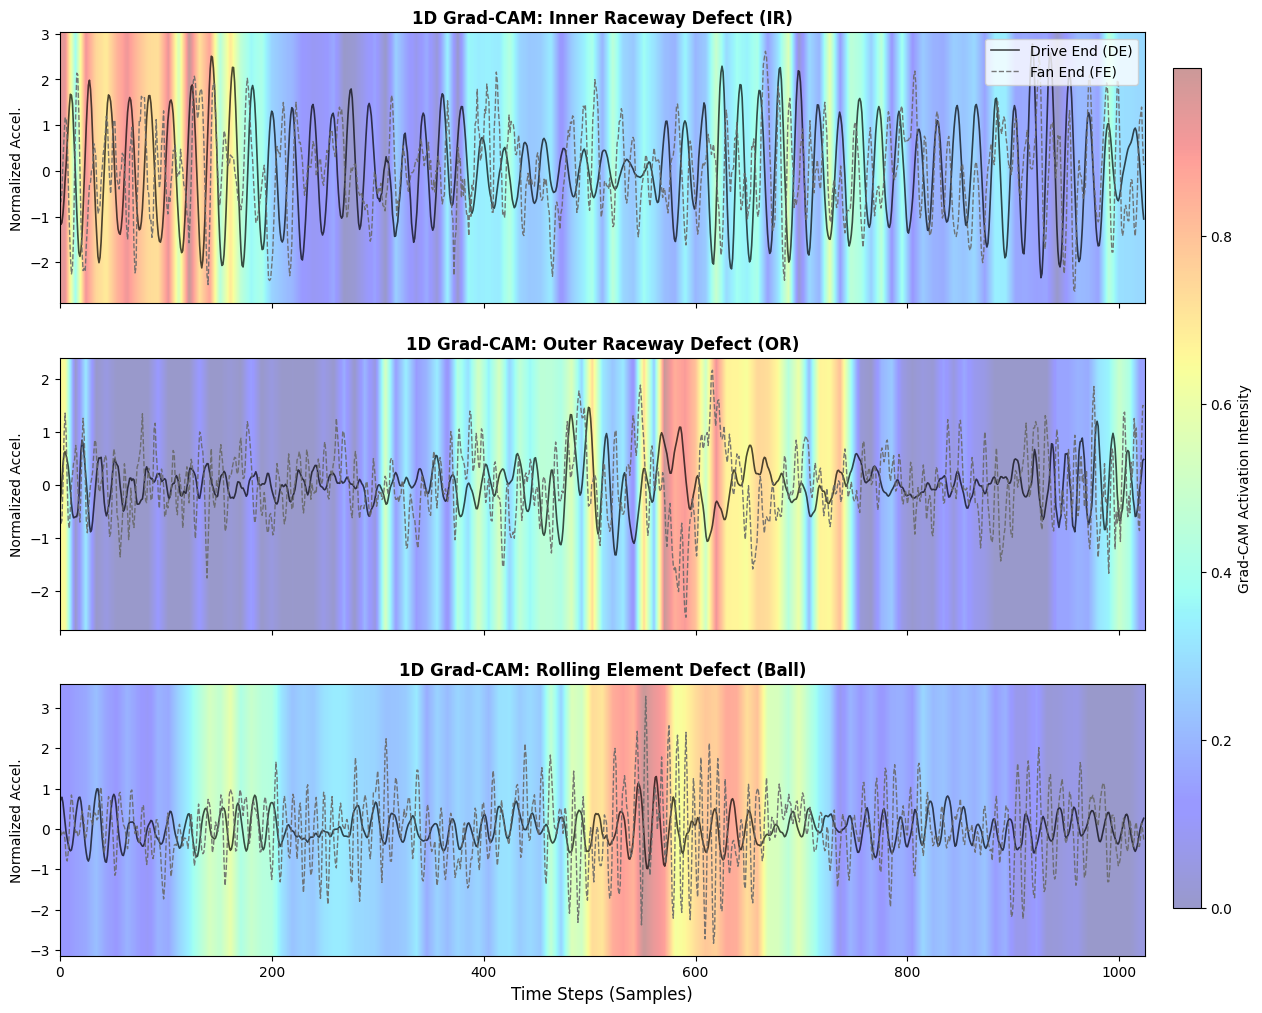

In [ ]:
class GradCAM1D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks to capture activations and gradients
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        # grad_output is a tuple, we want the first element
        self.gradients = grad_output[0].detach()

    def generate_cam(self, input_tensor, target_class):
        self.model.eval()
        
        # Forward pass
        output = self.model(input_tensor)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
            
        # Get the score for the target class
        score = output[:, target_class]
        
        # Backward pass
        self.model.zero_grad()
        score.backward(retain_graph=True)
        
        # Get gradients and activations captured by the hooks
        gradients = self.gradients
        activations = self.activations
        
        # Global Average Pooling (GAP) of gradients across the sequence length (dim=2)
        weights = torch.mean(gradients, dim=2, keepdim=True)
        
        # Weighted sum of activations
        cam = torch.sum(weights * activations, dim=1, keepdim=True)
        
        # Apply ReLU to only keep features that have a positive influence on the class
        cam = F.relu(cam)
        
        # Upsample the CAM back to the original sequence length (1024)
        cam = F.interpolate(cam, size=input_tensor.shape[2], mode='linear', align_corners=False)
        
        # Min-Max Normalization to scale between 0 and 1
        cam = cam - torch.min(cam)
        cam = cam / (torch.max(cam) + 1e-8)
        
        return cam.squeeze().cpu().numpy()

# Initialize Grad-CAM on the final Conv1d layer
# In the architecture, self.cnn is: Conv1d(0), ReLU(1), MaxPool(2), Conv1d(3), ReLU(4), MaxPool(5)
target_layer = model.cnn[3]
grad_cam = GradCAM1D(model, target_layer)

# Define the specific defect classes we want to plot (excluding 'Normal')
defect_classes = {
    1: 'Inner Raceway Defect (IR)',
    2: 'Outer Raceway Defect (OR)',
    3: 'Rolling Element Defect (Ball)'
}

fig, axes = plt.subplots(len(defect_classes), 1, figsize=(14, 12), sharex=True)

# Loop through defects to generate and plot the CAM
for i, (class_idx, class_name) in enumerate(defect_classes.items()):
    
    # Find an instance of this specific defect in the clean test set
    if class_idx == 2: sample_idx = np.where(y_test == class_idx)[0][5]
    else: sample_idx = np.where(y_test == class_idx)[0][0]
    
    # Extract the numpy arrays for plotting
    sample_np = X_test[sample_idx]
    de_signal = sample_np[0]
    fe_signal = sample_np[1]
    
    # Convert to tensor and add batch dimension for the model
    input_tensor = torch.tensor(sample_np, dtype=torch.float32).unsqueeze(0).to(device)
    
    # Generate the Grad-CAM heatmap for the specific class
    cam = grad_cam.generate_cam(input_tensor, target_class=class_idx)
    
    # Plot the original signals
    ax = axes[i]
    ax.plot(de_signal, label='Drive End (DE)', color='black', alpha=0.7, linewidth=1.2)
    ax.plot(fe_signal, label='Fan End (FE)', color='dimgray', alpha=0.9, linestyle='--', linewidth=1.0)
    
    # Overlay the CAM as a heatmap
    ymin, ymax = ax.get_ylim() # Determine y-axis limits to correctly bound heatmap image
    
    # Use imshow to overlay the gradient map
    im = ax.imshow(cam.reshape(1, -1), aspect='auto', cmap='jet', alpha=0.4, 
                   extent=[0, WINDOW_SIZE, ymin, ymax], interpolation='bilinear')
    
    ax.set_title(f"1D Grad-CAM: {class_name}", fontweight='bold', fontsize=12)
    ax.set_ylabel("Normalized Accel.")
    if i == 0:
        ax.legend(loc='upper right')

# colorbar to the figure to represent the heatmap intensity
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
fig.colorbar(im, cax=cbar_ax, label='Grad-CAM Activation Intensity')
axes[-1].set_xlabel("Time Steps (Samples)", fontsize=12)
plt.subplots_adjust(right=0.9) # Make room for the colorbar
plt.savefig(f"{folder_name}/gradcam_1d_analysis.png", bbox_inches='tight', dpi=300)
plt.show()